# VoxelMorph 2D — Inference

In [8]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from network import VoxelMorphUNet
from spatial_transform import SpatialTransformer
from dataset import MNISTDataset
from utils import jaccard_index

In [9]:
MODEL_PATH = "../trained_models/20260330_012958/best_model.pth"
DATA_PATH  = "../data/mnist_normalized_32x32.npz"
N_SAMPLES  = 8   

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VoxelMorphUNet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

stn = SpatialTransformer().to(device)

print(f"Loaded model from: {MODEL_PATH}")
print(f"Running on: {device}")

Loaded model from: trained_models/20260330_012958/best_model.pth
Running on: cuda


In [11]:
test_dataset = MNISTDataset(DATA_PATH, split="test")

# Pick N_SAMPLES random indices from the test set
indices = random.sample(range(len(test_dataset)), N_SAMPLES)

samples = []  
with torch.no_grad():
    for idx in indices:
        fixed, moving = test_dataset[idx]
        fixed  = fixed.unsqueeze(0).to(device)   # [1, 1, 32, 32]
        moving = moving.unsqueeze(0).to(device)

        flow  = model(torch.cat([fixed, moving], dim=1))
        moved = stn(moving, flow)

        samples.append((
            fixed.squeeze().cpu().numpy(),
            moving.squeeze().cpu().numpy(),
            moved.squeeze().cpu().numpy(),
            flow.squeeze().cpu().numpy(),   # [2, 32, 32]
        ))

print(f"Registered {N_SAMPLES} pairs.")

Registered 8 pairs.


In [12]:
# Jaccard index over the full test set
# Every image is used as moving; fixed is sampled randomly from the same class.
model.eval()
total_jaccard = 0.0

with torch.no_grad():
    for idx in range(len(test_dataset)):
        moving_img = test_dataset.images[idx]
        label = test_dataset.labels[idx]
        fixed_idx = int(random.choice(test_dataset.class_indices[label]))
        fixed_img = test_dataset.images[fixed_idx]

        moving_t = torch.from_numpy(moving_img).unsqueeze(0).unsqueeze(0).float().to(device)
        fixed_t = torch.from_numpy(fixed_img).unsqueeze(0).unsqueeze(0).float().to(device)

        flow = model(torch.cat([fixed_t, moving_t], dim=1))
        moved_t = stn(moving_t, flow)

        total_jaccard += jaccard_index(fixed_t, moved_t).item()

mean_jaccard = total_jaccard / len(test_dataset)
print(f"Mean Jaccard index over test set: {mean_jaccard:.4f}")

Mean Jaccard index over test set: 0.9038


## Visualizations

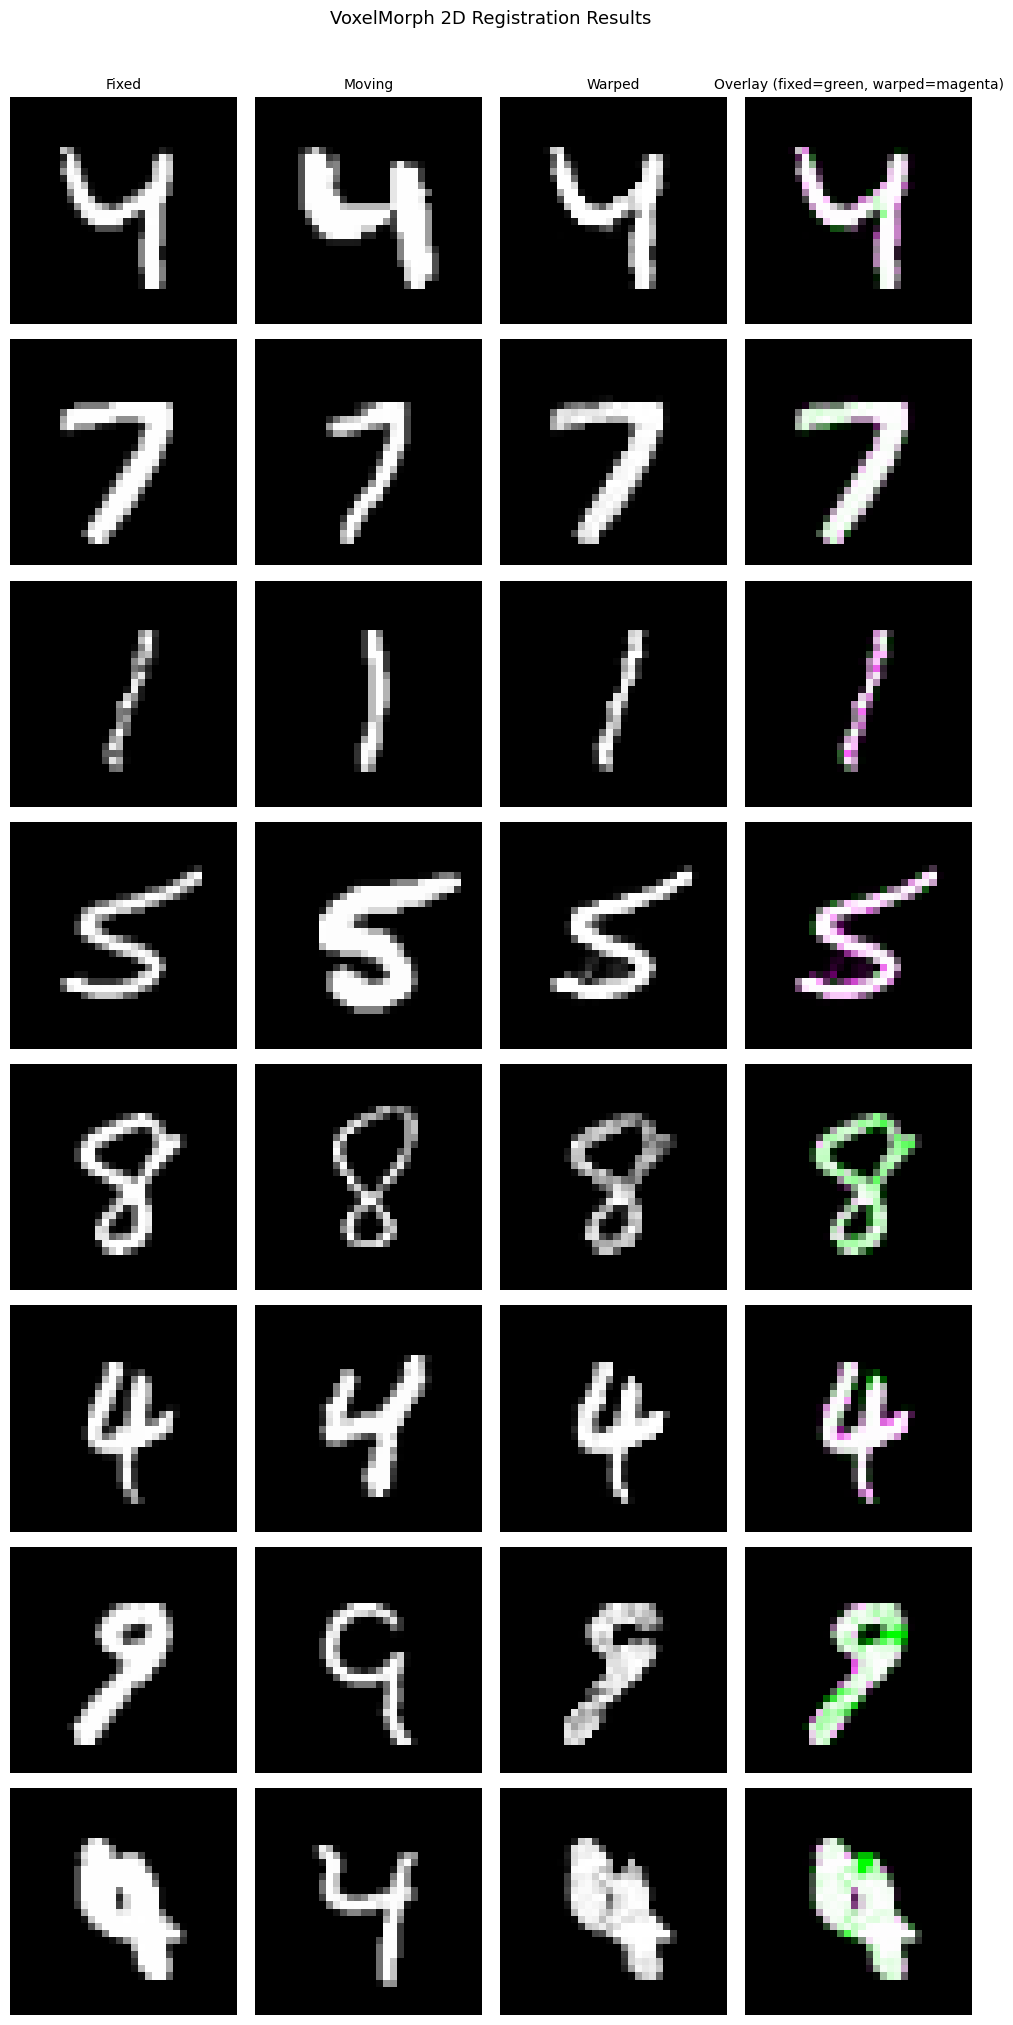

In [13]:
fig, axes = plt.subplots(N_SAMPLES, 4, figsize=(10, 2.5 * N_SAMPLES))
col_titles = ["Fixed", "Moving", "Warped", "Overlay (fixed=green, warped=magenta)"]

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10)

for row, (fixed, moving, moved, _) in enumerate(samples):
    # Normalise each image to [0, 1] for display
    def norm(img):
        lo, hi = img.min(), img.max()
        return (img - lo) / (hi - lo + 1e-6)

    f = norm(fixed)
    mo = norm(moving)
    wd = norm(moved)

    # Overlay: fixed in green channel, warped in magenta (R+B)
    overlay = np.zeros((32, 32, 3))
    overlay[:, :, 1] = f    # green  = fixed
    overlay[:, :, 0] = wd   # red    ┐
    overlay[:, :, 2] = wd   # blue   ┘ = warped → magenta

    axes[row, 0].imshow(f,       cmap="gray", vmin=0, vmax=1)
    axes[row, 1].imshow(mo,      cmap="gray", vmin=0, vmax=1)
    axes[row, 2].imshow(wd,      cmap="gray", vmin=0, vmax=1)
    axes[row, 3].imshow(overlay, vmin=0, vmax=1)

    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("VoxelMorph 2D Registration Results", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()